# Étape 1 — Exploration et nettoyage du jeu d'images IRM

**Objectif** : vérifier que les données correspondent à leur description, repérer les problèmes de qualité, et produire un inventaire propre pour l'étape 2 (extraction de features).

**Sommaire**
1. Volume et répartition des images
2. Format technique des images
3. Comparaison visuelle des classes
4. Doublons et risque de fuite de données
5. Vérification du biais de plan de coupe
6. Synthèse

## 1. Volume et répartition des images

L'énoncé indique ;

Ce jeu de données comprend un total de 1500 images :
    1400 images non étiquetées
    100 images étiquetées

Les images étiquetées sont réparties en deux catégories :
    Normal : Images de cerveaux sains.
    Cancer : Images de cerveaux présentant des signes de tumeurs.

Regardons cela

In [1]:
from pathlib import Path

dossiers = {
    "sans label": Path("../sans_label"),
    "de cancer": Path("../avec_labels/cancer"),
    "normales": Path("../avec_labels/normal"),
}
for nom, dossier in dossiers.items():
    fichiers = list(dossier.glob("*.jpg"))
    print(f"Nombre d'images {nom} : {len(fichiers)}")


Nombre d'images sans label : 1406
Nombre d'images de cancer : 50
Nombre d'images normales : 50


On note qu'il y a en effet 100 images étiquetées, sans déséquilibre de classe (50/50 pour avec ou sans cancer). Mais on note 1406 images non étiquetées (vs 1400 annoncées).

### 1.1 Inventaire des images dans un tableau

In [2]:
import pandas as pd

DOSSIER_LABELS = Path("../avec_labels")
DOSSIER_SANS = Path("../sans_label")

lignes = []   # liste vide : chaque image y ajoutera son dictionnaire

# 1) Les images labellisées : deux boucles imbriquées
for classe in ["cancer", "normal"]:
    for chemin in sorted((DOSSIER_LABELS / classe).glob("*.jpg")):
        lignes.append({"chemin": chemin, "source": "avec_labels", "label": classe})

# 2) Les images sans label : une seule boucle
for chemin in sorted(DOSSIER_SANS.glob("*.jpg")):
    lignes.append({"chemin": chemin, "source": "sans_label", "label": None})

# 3) La liste de dictionnaires devient un tableau
df = pd.DataFrame(lignes)

print(f"{len(df)} images au total")
df.head()

1506 images au total


,chemin,source,label
0,../avec_labels/cancer/05340cd4-3bb2-459d-9937-...,avec_labels,cancer
1,../avec_labels/cancer/0c6f3641-60d9-4a76-abe5-...,avec_labels,cancer
2,../avec_labels/cancer/0f718241-8f63-4b55-81ce-...,avec_labels,cancer
3,../avec_labels/cancer/11a7a426-4806-401e-98b2-...,avec_labels,cancer
4,../avec_labels/cancer/1c043dbb-4623-4769-8e5e-...,avec_labels,cancer


In [3]:
df.value_counts(["source", "label"], dropna=False)

source       label 
sans_label   NaN       1406
avec_labels  cancer      50
             normal      50
Name: count, dtype: int64

## 2. Format technique des image

Dans la description du jeu de données, il est indiqué ;

Caractéristiques des Images

Toutes les images ont été redimensionnées à une taille standardisée de 512×512 pixels. Cette standardisation assure leur compatibilité avec divers pipelines de traitement d'images et d'apprentissage automatique. Elles sont enregistrées au format d'image courant JPEG (.jpg).

Vérifions également cela

In [4]:
from PIL import Image

chemin = df["chemin"].iloc[0]   # le chemin de la 1re image du tableau
print(chemin)

with Image.open(chemin) as img:
    print("largeur :", img.width)
    print("hauteur :", img.height)
    print("mode    :", img.mode)
    print("format  :", img.format)


../avec_labels/cancer/05340cd4-3bb2-459d-9937-bf27d52d8351.jpg
largeur : 512
hauteur : 512
mode    : RGB
format  : JPEG


In [5]:
def lire_proprietes(chemin):
    """Renvoie les propriétés techniques d'une image sous forme de dictionnaire."""
    with Image.open(chemin) as img:
        return {
            "largeur": img.width,
            "hauteur": img.height,
            "mode": img.mode,
            "format": img.format,
        }

# Test de la fonction sur la même image avant de l'appliquer partout
lire_proprietes(df["chemin"].iloc[0])


{'largeur': 512, 'hauteur': 512, 'mode': 'RGB', 'format': 'JPEG'}

In [6]:
props = [lire_proprietes(c) for c in df["chemin"]]
df = pd.concat([df, pd.DataFrame(props)], axis=1)

df.value_counts(["source", "largeur", "hauteur", "mode", "format"])

source       largeur  hauteur  mode  format
sans_label   512      512      RGB   JPEG      1406
avec_labels  512      512      RGB   JPEG       100
Name: count, dtype: int64

Les images sont bien au format JPEG, elles ont bien une taille standardisée de 512x512 pixels. Néanmoins elles sont enregistrées en couleur (RGB), ce qui est étonnant pour des IRM qui n'ont besoin que de niveaux de gris.

### 2.1 Couleur ou niveaux de gris ?

In [7]:
import numpy as np
import matplotlib.pyplot as plt

chemin = df["chemin"].iloc[0]
tableau = np.asarray(Image.open(chemin))   # transforme l'image en tableau numpy

print("forme :", tableau.shape)   # (hauteur, largeur, nombre de canaux)
print("type  :", tableau.dtype)   # le type des nombres stockés
print("min   :", tableau.min(), "  max :", tableau.max())

# Un pixel au centre de l'image : ses 3 valeurs R, V, B
print("pixel central :", tableau[256, 256])

forme : (512, 512, 3)
type  : uint8
min   : 0   max : 255
pixel central : [67 67 67]


R = V = B --> images en niveaux de gris stockées sur 3 canaux identiques, format directement compatible avec ResNet.

## 3. Comparaison visuelle des classes

Affichons 8 images par groupe, et regardons si les images diffèrent par autre chose que la tumeur

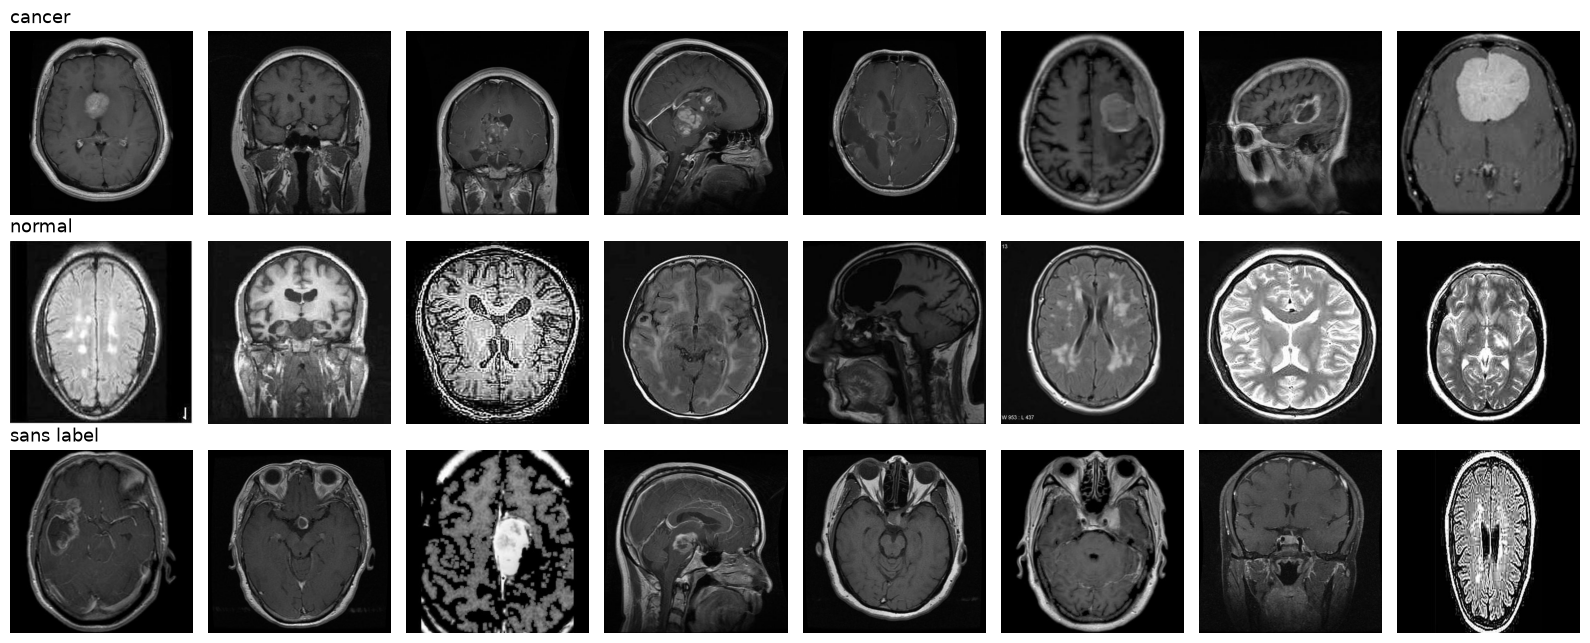

In [8]:
import matplotlib.pyplot as plt

groupes = {
    "cancer": df["label"] == "cancer",
    "normal": df["label"] == "normal",
    "sans label": df["source"] == "sans_label",
}

fig, axes = plt.subplots(3, 8, figsize=(16, 6.5))   # grille de 3 lignes × 8 colonnes

for ligne, (nom, masque) in enumerate(groupes.items()):
    echantillon = df[masque].sample(8, random_state=42)   # 8 images au hasard (reproductible)
    for col, chemin in enumerate(echantillon["chemin"]):
        axes[ligne, col].imshow(Image.open(chemin))
        axes[ligne, col].axis("off")
    axes[ligne, 0].set_title(nom, loc="left", fontsize=13)

plt.tight_layout()
plt.show()


On peut noter :
- une luminosité assez homogène pour les images labellisées « cancer », plutôt sombres ; les images « normal » sont plus variées, certaines très claires ;
- les images « cancer » présentent différents plans de coupe (axial = vue du dessus, coronal = vue de face, sagittal = vue de profil), tandis que les images « normal » et « sans label » sont presque toutes des coupes axiales.

Conséquence : si les deux classes diffèrent par le plan de coupe, le clustering risque de regrouper les images selon le plan de coupe, et non selon la présence d'une tumeur.

*Hypothèse formulée sur 8 images par groupe, vérifiée plus bas sur 50 images.*

## 4. Doublons et risque de fuite de données

Regardons maintenant s'il y a des doublons dans notre jeu de données. C'est important, notamment pour éviter qu'un exemple du jeu d'entrainement se retrouve également dans le jeu de test (data leakage).

In [10]:
import hashlib

# Empreinte MD5 : deux fichiers identiques ont exactement la même empreinte
df["md5"] = df["chemin"].apply(lambda c: hashlib.md5(c.read_bytes()).hexdigest())
print("Fichiers :", len(df), "| contenus différents :", df["md5"].nunique())

md5_labellises = set(df.loc[df["source"] == "avec_labels", "md5"])

Fichiers : 1506 | contenus différents : 1410


In [13]:
labellisees = df[df["source"] == "avec_labels"]
sans = df[df["source"] == "sans_label"]

# Cas 1 : doublons à l'intérieur des images labellisées
n_internes_labels = labellisees.duplicated("md5").sum()

# Cas 2 : images de sans_label qui sont des copies d'images labellisées
n_copies = sans["md5"].isin(md5_labellises).sum()

# Cas 3 : doublons à l'intérieur de sans_label (une fois les copies du cas 2 retirées)
sans_restantes = sans[~sans["md5"].isin(md5_labellises)]
n_internes_sans = sans_restantes.duplicated("md5").sum()

print("Doublons internes aux labellisées       :", n_internes_labels)
print("Copies d'images labellisées (sans_label):", n_copies)
print("Doublons internes à sans_label          :", n_internes_sans)
print("Total                                   :", n_internes_labels + n_copies + n_internes_sans)


Doublons internes aux labellisées       : 1
Copies d'images labellisées (sans_label): 32
Doublons internes à sans_label          : 63
Total                                   : 96


Il y a donc 96 fichiers en double :
- 32 copies d'images labellisées dans `sans_label` : nous les supprimons de `sans_label` (risque de fuite de données) ;
- 63 doublons à l'intérieur de `sans_label` ;
- 1 doublon parmi les images labellisées (normal).

In [11]:
# Une seule copie par image côté labellisé
labels_propres = df[df["source"] == "avec_labels"].drop_duplicates("md5")

# Côté sans label : on retire les copies d'images labellisées (~ = NON), puis les doublons
sans_propres = df[(df["source"] == "sans_label") & ~df["md5"].isin(md5_labellises)].drop_duplicates("md5")

df_propre = pd.concat([labels_propres, sans_propres], ignore_index=True)
print(df_propre.value_counts(["source", "label"], dropna=False))

Path("../data").mkdir(exist_ok=True)
df_propre[["chemin", "source", "label"]].to_csv("../data/inventaire.csv", index=False)


source       label 
sans_label   NaN       1311
avec_labels  cancer      50
             normal      49
Name: count, dtype: int64


Nous avons donc 99 images labellisées (50 cancer / 49 normal -- notre doublon sur les données labellisées a bien été supprimé) + 1311 sans label après nettoyage. Le déséquilibre 50/49 est négligeable.

## 5. Vérification du biais de plan de coupe

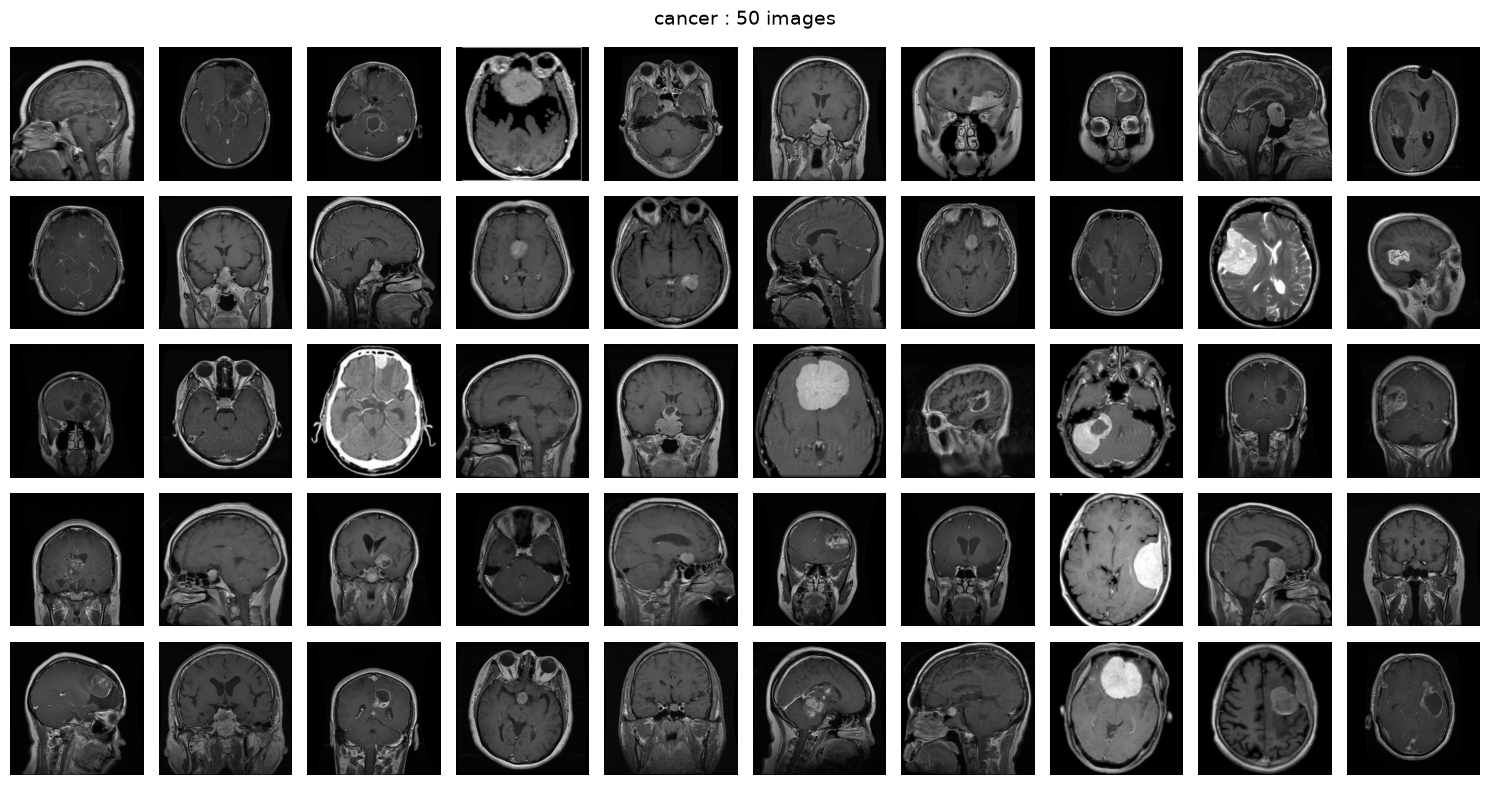

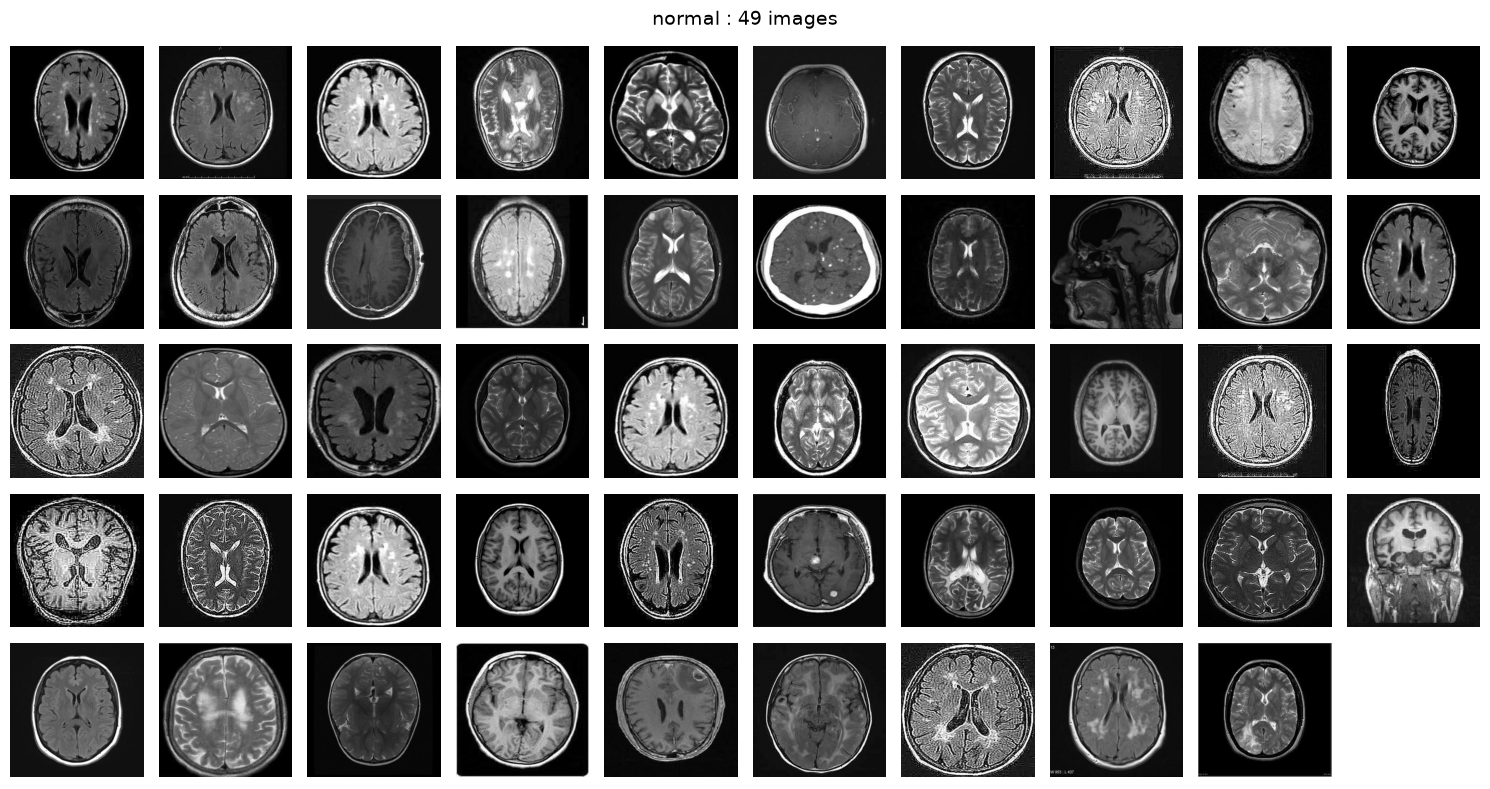

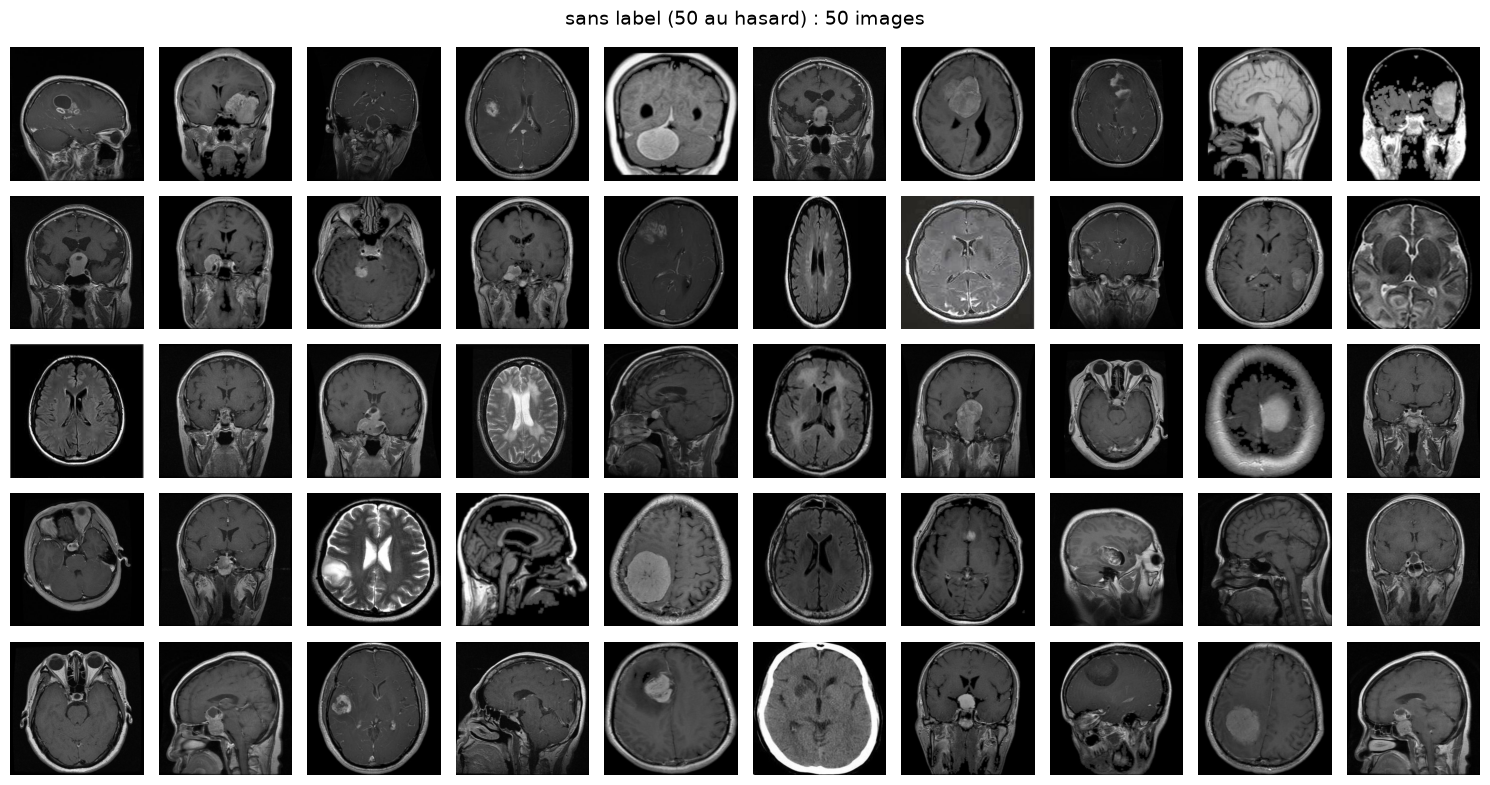

In [12]:
groupes_propres = {
    "cancer": df_propre[df_propre["label"] == "cancer"],
    "normal": df_propre[df_propre["label"] == "normal"],
    "sans label (50 au hasard)": df_propre[df_propre["source"] == "sans_label"].sample(50, random_state=42),
}

for nom, sous_tableau in groupes_propres.items():
    chemins = sous_tableau["chemin"]
    fig, axes = plt.subplots(5, 10, figsize=(15, 8))
    for ax in axes.flat:
        ax.axis("off")
    for ax, chemin in zip(axes.flat, chemins):
        ax.imshow(Image.open(chemin))
    fig.suptitle(f"{nom} : {len(chemins)} images", fontsize=14)
    plt.tight_layout()
    plt.show()

| Groupe | Coupes non axiales (environ) |
|---|---|
| cancer | 17/50 (34 %) |
| normal | 1/49 (2 %) |
| sans label | 9/50 (18 %) |

L'hypothèse est confirmée : les images « cancer » présentent des plans de coupe beaucoup plus variés que les images « normal ». Les images « sans label » occupent une position intermédiaire, probablement parce qu'elles mélangent les deux classes. Si elles étaient réparties moitié-moitié, on attendrait environ (34 % + 2 %) / 2 ≈ 18 %, ce qui correspond à notre comptage. C'est un indice, pas une preuve : l'échantillon est petit.

## 6. Synthèse

| Point | Constat | Conséquence pour la suite |
|---|---|---|
| Volume | 100 images labellisées (50/50) + 1406 sans label | très peu de labels : l'approche semi-supervisée a tout son sens |
| Format | 512×512, JPEG, niveaux de gris stockés sur 3 canaux identiques | directement compatible avec un ResNet pré-entraîné |
| Doublons | 96 fichiers en double, dont 32 images labellisées recopiées dans `sans_label` | supprimés pour éviter la fuite de données. L'écart 1406 / 1400 annoncé s'explique par 95 doublons dans `sans_label` |
| Après nettoyage | **99 images labellisées (50 cancer / 49 normal) + 1311 sans label** | inventaire sauvegardé dans `data/inventaire.csv`, point de départ de l'étape 2 |
| Biais | « cancer » : 34 % de coupes non axiales, contre 2 % pour « normal » | risque que le clustering, voire le modèle, apprenne le plan de coupe au lieu de la tumeur |

**Question pour la suite** : faut-il corriger ce biais (par exemple en ne gardant que les coupes axiales) ou seulement le documenter ?